## Machine Learning

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [238]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [239]:
import matplotlib as mpl
import matplotlib.pyplot as plt
#-------------------------Estilos para los gráficos. 
plt.style.use("seaborn-v0_8-ticks") ##Estilo general
mpl.rcParams["font.family"]="Times New Roman"     
mpl.rcParams["font.weight"]="normal"  
##Leyenda
mpl.rcParams["legend.fancybox"]=True    ##Caja de la leyenda con esquinas redondeadas
##Ejes
mpl.rcParams["axes.facecolor"]="white"
##Figura
mpl.rcParams["figure.facecolor"]="white"

##Paleta de colores propia
from matplotlib.colors import ListedColormap

##Tonos del celeste al mostaza
colores1 = ['#8ecae6','#219ebc','#126782','#023047','#ffb703','#fd9e02','#fb8500']
mapa1 = plt.get_cmap(ListedColormap(colores1))


In [240]:
##Leer todos los datos

#PM2.5
tra_inicial = pd.read_csv('tra.csv')
fis_inicial = pd.read_csv('fis.csv')
inm_inicial = pd.read_csv('inm.csv')
bel_inicial = pd.read_csv('bel.csv')
ele_inicial = pd.read_csv('ele.csv')
ara_inicial = pd.read_csv('ara.csv')
alt_inicial = pd.read_csv('alt.csv')
vil_inicial = pd.read_csv('vil.csv')

pm25_inicial = [tra_inicial,fis_inicial,inm_inicial,bel_inicial,ele_inicial,ara_inicial,alt_inicial,vil_inicial]
#Meteorología
met_419 = pd.read_csv('estacion_419_horario.csv')
met_478 = pd.read_csv('estacion_478_horario.csv')
met_362 = pd.read_csv('estacion_362_horario.csv')
met_197 = pd.read_csv('estacion_197_horario.csv')
met_355 = pd.read_csv('estacion_355_horario.csv')
met_603 = pd.read_csv('estacion_603_horario.csv')
met_367 = pd.read_csv('estacion_367_horario.csv')



meteo = [met_419,met_478,met_362,met_197,met_355,met_603,met_197,met_367]
##Filtrar el PM2.5

pm25 = []
for i, col in enumerate(pm25_inicial):
    ##Castear los datos
    pm25_inicial[i]['fecha'] = pd.to_datetime(pm25_inicial[i]['fecha'])
    meteo[i]['fecha'] = pd.to_datetime(meteo[i]['fecha'])
    pm25_inicial[i]['pm25'] = pm25_inicial[i]['pm25'].astype(np.float32)

    ##Añadir datos filtrados al nuevo conjunto
    pm25.append(pm25_inicial[i].loc[pm25_inicial[i]['fecha']>='2022'])
    
##Unificar los datos de PM2.5 y meteorologia

unidos = []
##Renombrar columnas
columnas = ['fecha','pm','t','h','p','v']
for i, col in enumerate(pm25):
    unidos.append(pd.concat([pm25[i].set_index('fecha'),meteo[i].set_index('fecha')],axis=1).reset_index())
    unidos[i].columns= columnas
##Optimizar el codigo
# del pm25_inicial, tra_inicial,fis_inicial,inm_inicial,bel_inicial,ele_inicial,ara_inicial,alt_inicial,vil_inicial
del met_419,met_478,met_362,met_197,met_355,met_603,met_367
del pm25, meteo


In [241]:
##Cantidad de datos por ubicación

lugares = ['Tráfico Centro','Fiscalía','INEM','Belén','Santa Elena','Aranjuez','Altavista','Villa Hermosa']
nulos = []
nulos_porcentaje = []
for i,col in enumerate(unidos):
    nulos.append(unidos[i]['pm'].isna().sum())
    nulos_porcentaje.append(round(nulos[i]/unidos[i].shape[0]*100,2))
df_nulos = pd.DataFrame({'Lugar':lugares,'Nulos':nulos,'Nulos (%)':nulos_porcentaje})
df_nulos.style.background_gradient()

,Lugar,Nulos,Nulos (%)
0,Tráfico Centro,832,4.770000
1,Fiscalía,723,4.160000
2,INEM,892,5.110000
3,Belén,597,3.420000
4,Santa Elena,1074,6.160000
5,Aranjuez,745,4.270000
6,Altavista,899,5.150000
7,Villa Hermosa,945,5.410000


In [242]:
# fig, ax = plt.subplots(figsize=(12,6),nrows=2, ncols=4)
# fig.suptitle('Boxplots de PM2.5')
# ax = ax.flat
# for i, col in enumerate(unidos):
#     ax[i].set_title(lugares[i])
#     sns.boxplot(data=unidos[i],ax=ax[i],y='pm')
#     ax[i].grid()
#     ax[i].set_ylabel('')
#     ax[i].set_yticks([])

# fig, ax = plt.subplots(figsize=(12,6),nrows=2, ncols=4)
# fig.suptitle('Boxplots de Temperatura')
# ax = ax.flat
# for i, col in enumerate(unidos):
#     ax[i].set_title(lugares[i])
#     sns.boxplot(data=unidos[i],ax=ax[i],y='t')
#     ax[i].grid()
#     ax[i].set_ylabel('')
#     ax[i].set_yticks([])


# fig, ax = plt.subplots(figsize=(12,6),nrows=2, ncols=4)
# fig.suptitle('Boxplots de Presión')
# ax = ax.flat
# for i, col in enumerate(unidos):
#     ax[i].set_title(lugares[i])
#     sns.boxplot(data=unidos[i],ax=ax[i],y='p')
#     ax[i].grid()
#     ax[i].set_ylabel('')
#     ax[i].set_yticks([])

# fig, ax = plt.subplots(figsize=(12,6),nrows=2, ncols=4)

# fig.suptitle('Boxplots de Humedad relativa')
# ax = ax.flat
# for i, col in enumerate(unidos):
#     ax[i].set_title(lugares[i])
#     sns.boxplot(data=unidos[i],ax=ax[i],y='h')
#     ax[i].grid()
#     ax[i].set_ylabel('')
#     ax[i].set_yticks([])

# fig, ax = plt.subplots(figsize=(12,6),nrows=2, ncols=4)

# fig.suptitle('Boxplots de Velocidad del viento')
# ax = ax.flat
# for i, col in enumerate(unidos):
#     ax[i].set_title(lugares[i])
#     sns.boxplot(data=unidos[i],ax=ax[i],y='v')
#     ax[i].grid()
#     ax[i].set_ylabel('')
#     ax[i].set_yticks([])




In [243]:
##Enfocarse en Belén
belen = bel_inicial.dropna().copy()

##Obtener nuevas columnas

belen['mes'] = belen['fecha'].dt.month
belen['año'] = belen['fecha'].dt.year
belen['semana'] = belen['fecha'].dt.isocalendar().week

# fig, ax = plt.subplots(figsize=(12,4))

# sns.boxplot(data=belen,y='pm',x='mes',legend=False,palette='coolwarm')

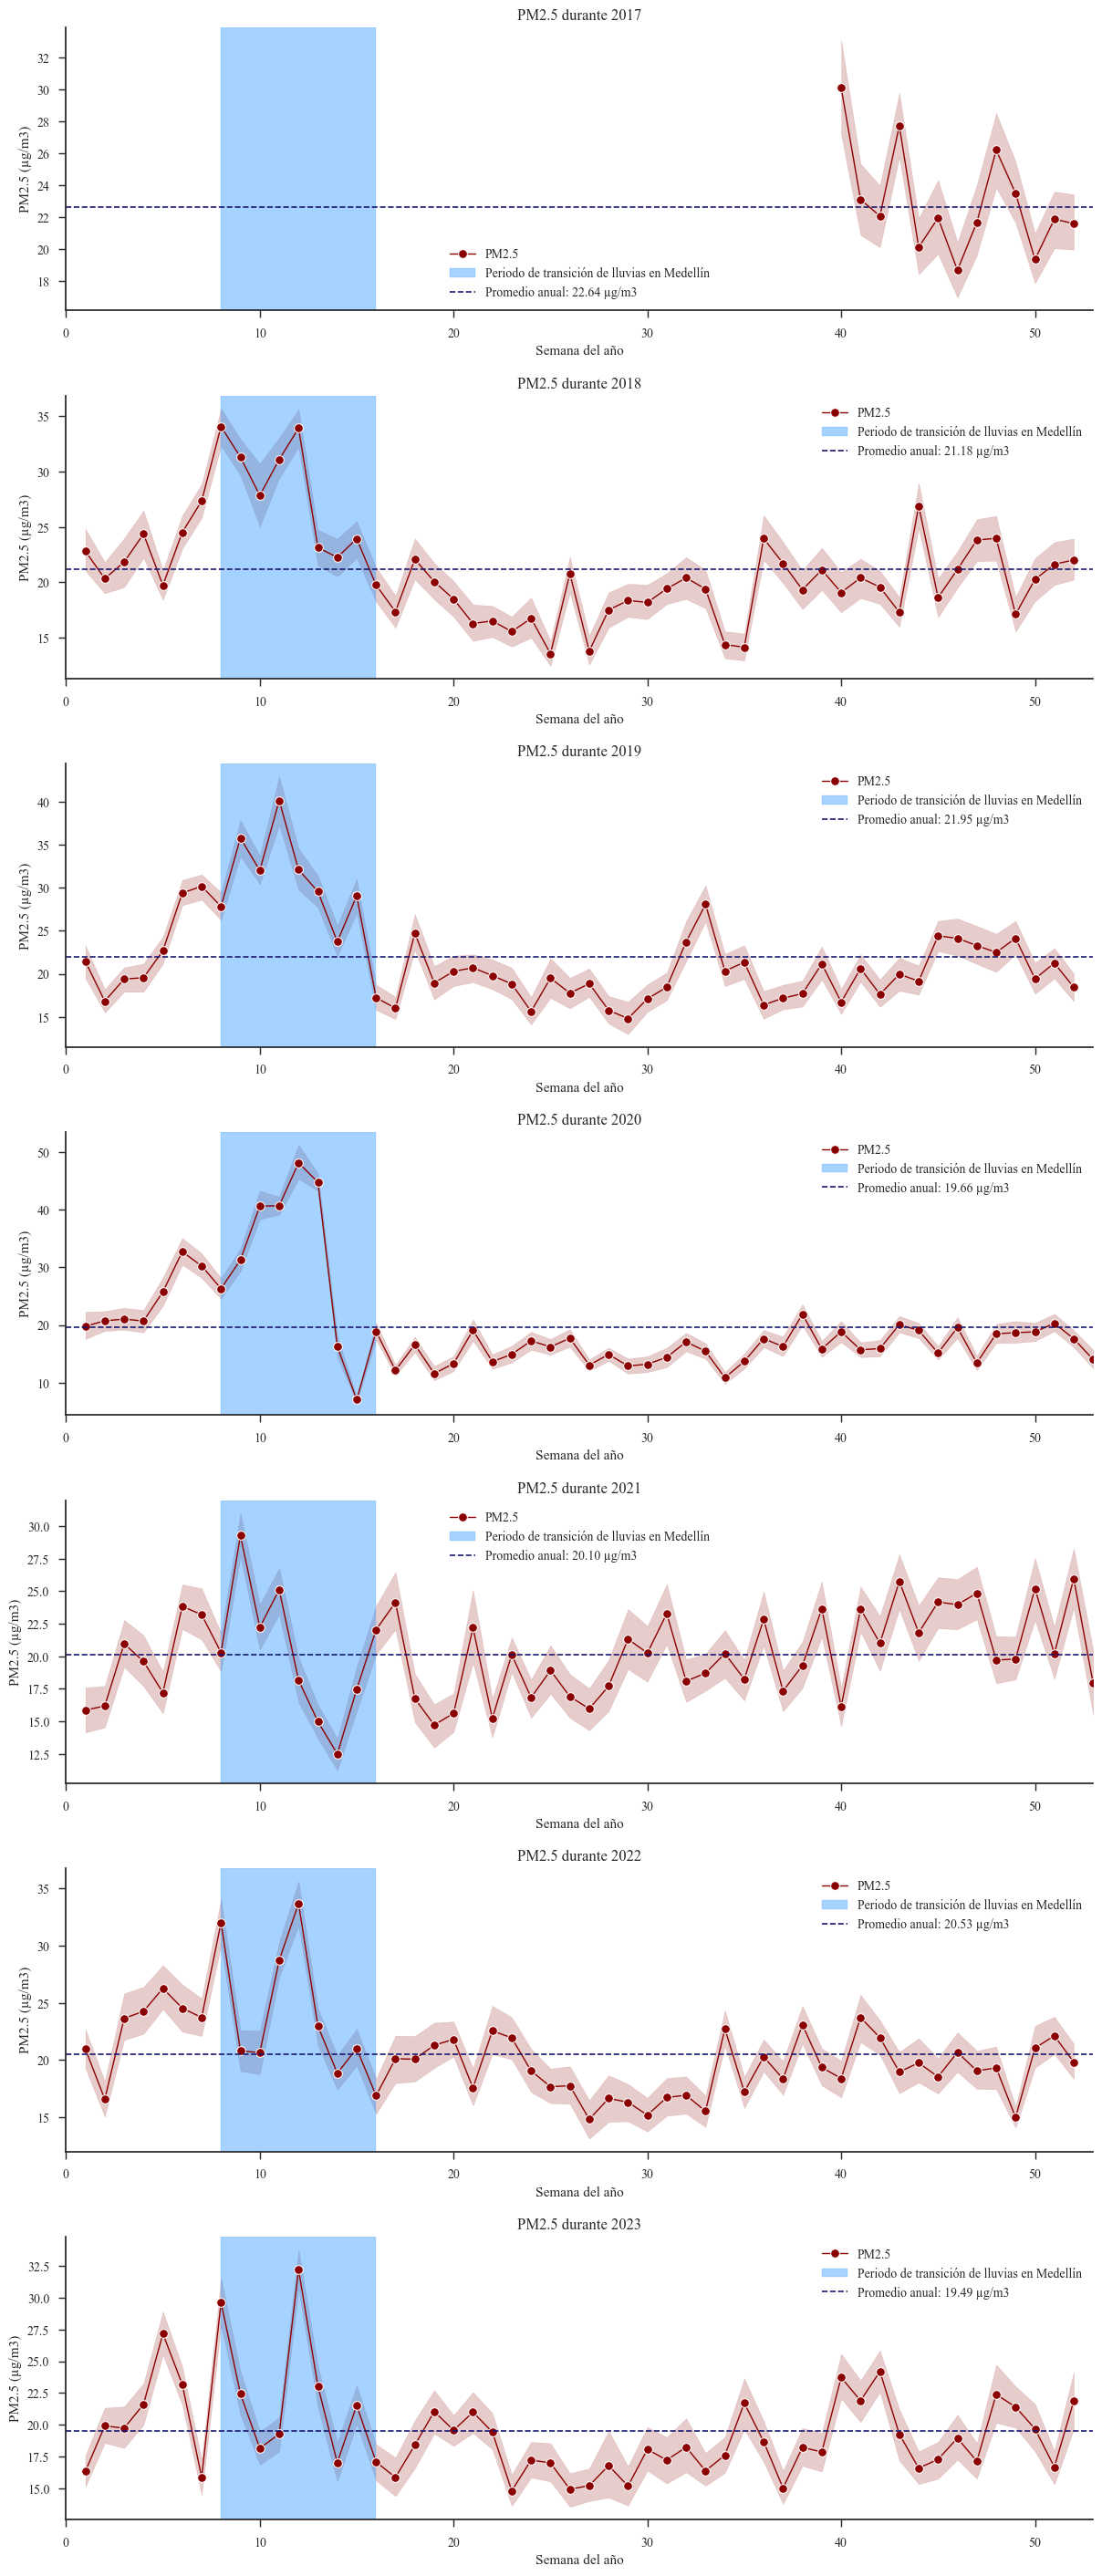

In [244]:
##Analisis por año

años = belen['año'].unique()

fig, ax = plt.subplots(figsize=(12,4*len(años)),nrows=len(años))
fig.tight_layout(h_pad=4)
for i,año in enumerate(años):
    pm_año = belen.loc[belen['año']==año]

    ##Linea del pm25 en el año x vs semanas de ese año
    sns.lineplot(data=pm_año,x='semana',y='pm25',ax=ax[i],lw=1,marker='o',color='darkred',label='PM2.5')

    ##Rango resaltado  "span" en las temporadas de lluvia
    ax[i].axvspan(8,16,label='Periodo de transición de lluvias en Medellín',color='dodgerblue',alpha=0.4)

    ##Lineas con el promedio anual
    promedio_anual = pm_año['pm25'].mean()
    ax[i].axhline(promedio_anual,label=f'Promedio anual: {pm_año["pm25"].mean():.2f} µg/m3',lw=1.2,ls='--',color='midnightblue')
    ##Titulos y etiquetas
    ax[i].set_title(f'PM2.5 durante {año}')
    ax[i].set_xlabel('Semana del año')
    ax[i].set_ylabel('PM2.5 (µg/m3)')
    ax[i].legend()
    ax[i].set_xlim(0,belen['semana'].max())
    

    

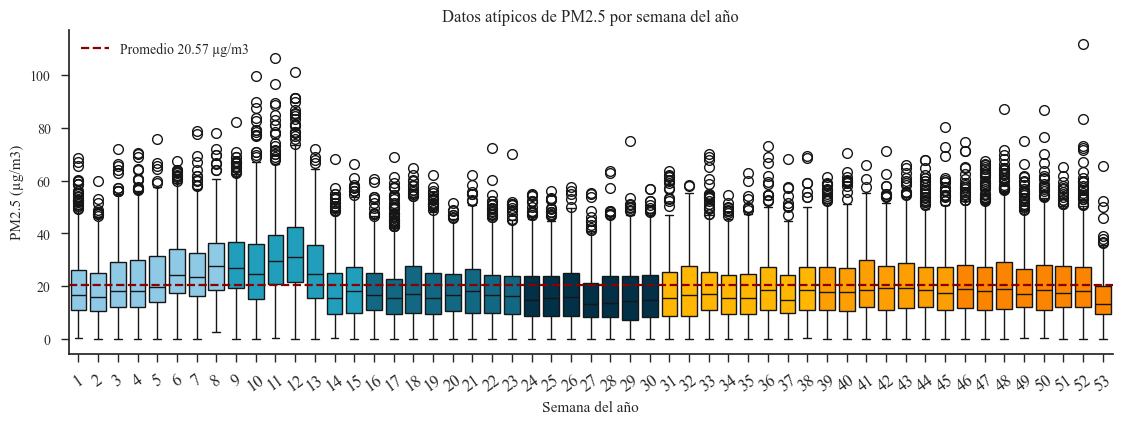

In [245]:
##Datos atipicos por semana

fig, ax = plt.subplots(figsize=(12,4))

sns.boxplot(data=belen,x='semana',y='pm25',hue='semana',palette=mapa1,saturation=1,legend=False)

ax.tick_params(axis='x',rotation=35,labelsize=12)
ax.set_ylabel('PM2.5 (µg/m3)')
ax.set_xlabel('Semana del año')
ax.set_title('Datos atípicos de PM2.5 por semana del año')
ax.axhline(belen['pm25'].mean(),color='darkred',label=f'Promedio {belen["pm25"].mean():.2f} µg/m3',lw=1.6,ls='--')
ax.legend()
plt.show()

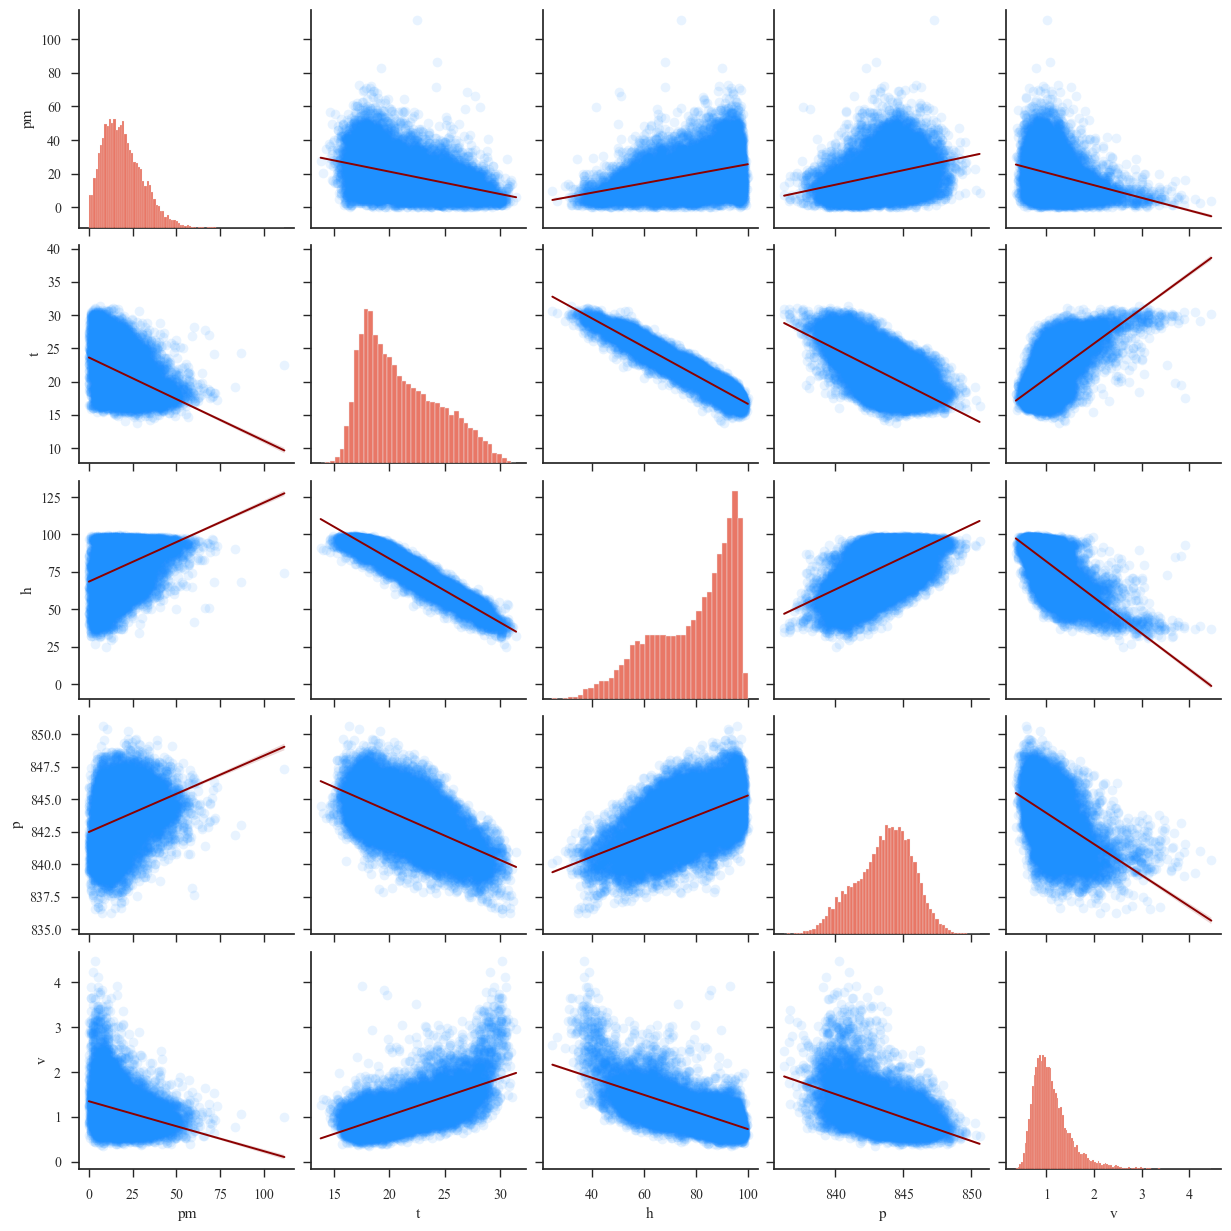

In [246]:
##Analisis unificado

##Formato horario
belen = unidos[3].dropna().copy()
belen_diario = belen.resample('D',on='fecha').mean().reset_index().dropna()
sns.pairplot(data=belen,kind='reg',plot_kws={
    'scatter_kws':{'alpha':0.1,'color':'dodgerblue'},
    'line_kws':{'color':'darkred','linewidth':1.4}
    })
plt.show()

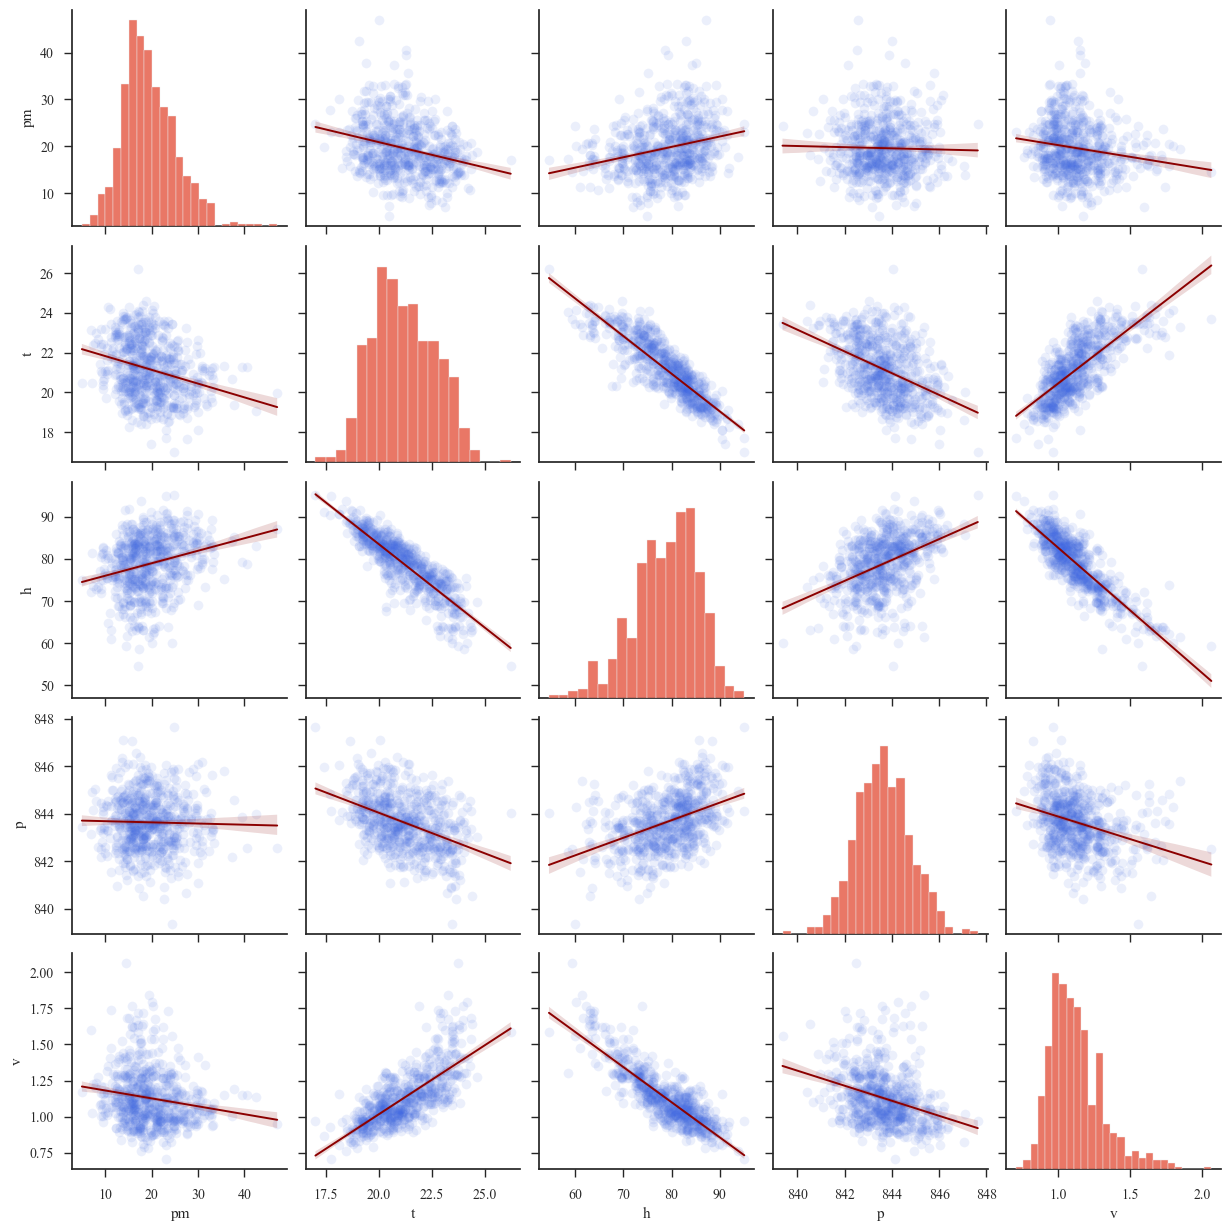

In [247]:

# ##analisis diario
sns.pairplot(data=belen_diario,kind='reg',plot_kws={
    'scatter_kws':{'alpha':0.1,'color':'royalblue'},
    'line_kws':{'color':'darkred','linewidth':1.4}
    })
plt.show()

<Axes: >

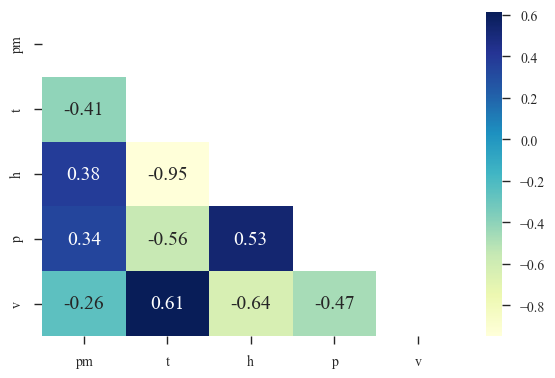

In [248]:
##Correlacion entre variables

corr = belen.drop(columns='fecha').corr(method='spearman')

mask = np.triu(np.ones_like(corr,dtype=bool))
fig, ax = plt.subplots(figsize=(6,4))
ax.grid(False)
sns.heatmap(corr,mask=mask,annot=True,cmap='YlGnBu',annot_kws={'size':14})

In [249]:
##Modelar una clasificacion
belen_diario['ICA'] = pd.cut(belen_diario['pm'],bins=[0,12,37,55],labels=[0,1,2])

belen_diario['semana'] = belen_diario['fecha'].dt.isocalendar().week
belen_diario['mes'] = belen_diario['fecha'].dt.month
belen_diario.drop(columns=['fecha','pm'],inplace=True)
x,y = belen_diario.drop(columns='ICA'),belen_diario['ICA']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=123)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier as xgb
from sklearn.metrics import f1_score, accuracy_score, recall_score
modelos = {
    'Regresión Logística': LogisticRegression(n_jobs=-1),
    'Arbol de decisiones': DecisionTreeClassifier(),
    'Bosque Aleatorio':RandomForestClassifier(n_jobs=-1),
    'Xgboost':xgb(n_jobs=-1)
}
f1 = []
recall = []
accuracy = []
comparaciones = []
def evaluar_modelos():
    for nombre, modelo in modelos.items():
        y_pred = modelo.fit(x_train, y_train).predict(x_test)
        f1.append(f1_score(y_test, y_pred,average='weighted'))
        recall.append(recall_score(y_test, y_pred,average='weighted'))
        accuracy.append(accuracy_score(y_test, y_pred))
        comparaciones.append(pd.DataFrame({'Real':y_test,f'{nombre}':y_pred}))
    rendimientos = pd.DataFrame({'Modelo':modelos.keys(),'F1':f1,'Recall':recall,'Accuracy':accuracy})

    return rendimientos, comparaciones

rendimientos,comparaciones = evaluar_modelos()
rendimientos

,Modelo,F1,Recall,Accuracy
0,Regresión Logística,0.926099,0.950311,0.950311
1,Arbol de decisiones,0.894042,0.888199,0.888199
2,Bosque Aleatorio,0.926099,0.950311,0.950311
3,Xgboost,0.919852,0.937888,0.937888


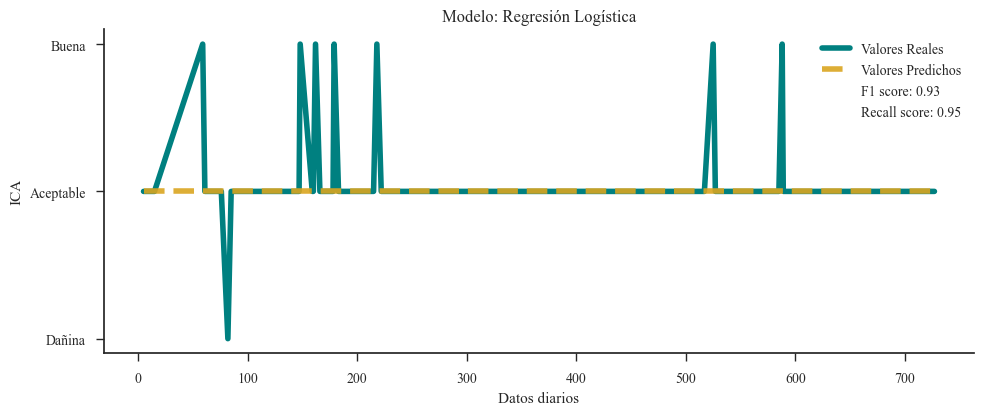

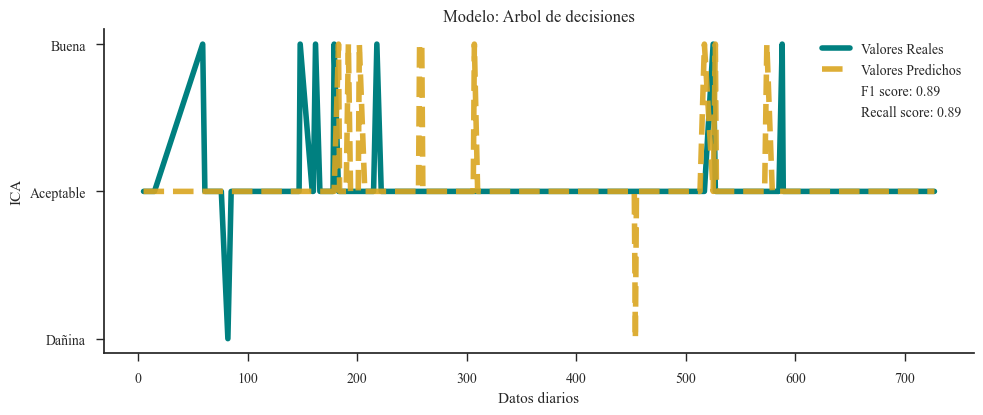

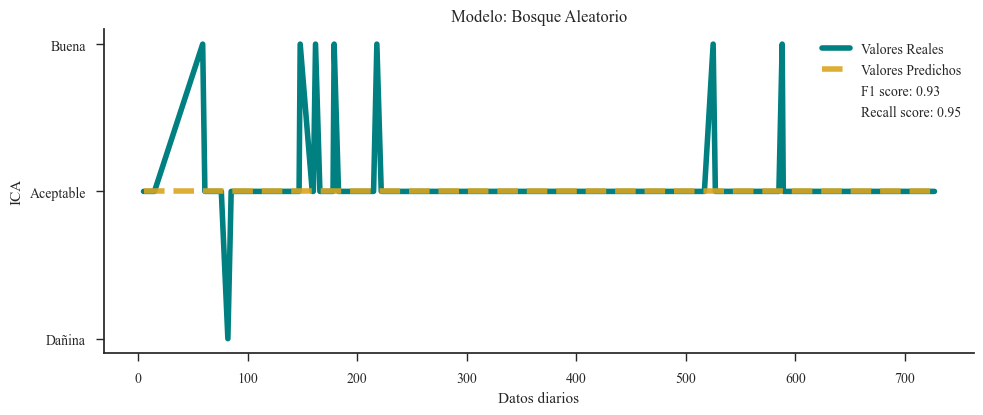

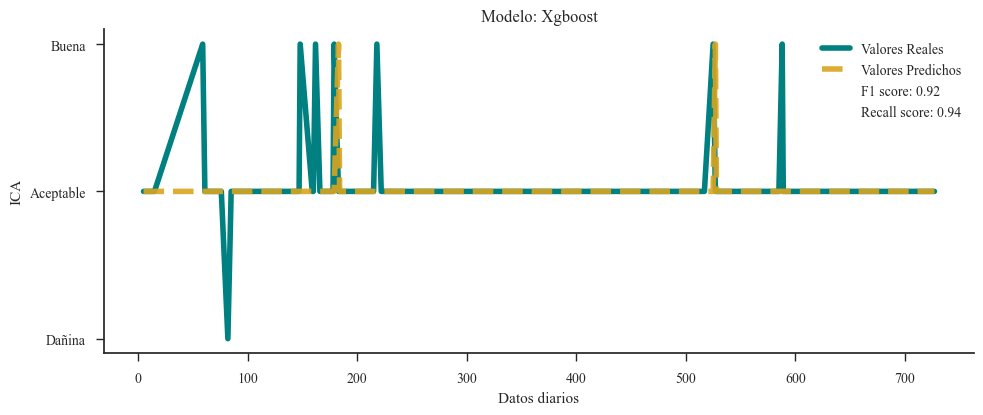

In [263]:
##Comparación visual de los modelos
for i,col in enumerate(comparaciones):
    fig, ax = plt.subplots(figsize=(10,4))
    sns.lineplot(data=comparaciones[i],x=comparaciones[i].index,y='Real',color='teal',lw=4,label='Valores Reales')
    sns.lineplot(data=comparaciones[i],x=comparaciones[i].index,y=f'{list(modelos.keys())[i]}',alpha=0.9,color='goldenrod',lw=4,ls='--',label='Valores Predichos')
    ##Mostrar los puntajes en el gráfico
    ax.axvline(10, alpha=0,label=f'F1 score: {rendimientos.iloc[i,1]:.2f}')
    ax.axvline(10, alpha=0,label=f'Recall score: {rendimientos.iloc[i,2]:.2f}')
    
    ax.set_title(f'Modelo: {list(modelos.keys())[i]}')
    ax.set_xlabel('Datos diarios')
    ax.set_yticks([2,1,0])
    ax.set_yticklabels(['Dañina','Aceptable','Buena'])
    ax.set_ylabel('ICA')
    ax.legend()
    plt.show()
    plt.close()
